# Tata Technologies TechPulse Applied AI/ML Laboratory
## Assignment 2: Simulated Driving Agent Behavior using Genetic Algorithm

### Objective
Build an autonomous self-driving agent that learns to navigate a 1-D multi-lane environment and avoid obstacles using a **Genetic Algorithm (GA)** in Python.

### Core Concepts
- **Environment:** 5 parallel driving lanes (`LANE_WIDTH = 5`), 40 timesteps per episode (`EPISODE_LEN = 40`), sensor range of 3 timesteps ahead (`SENSOR_RANGE = 3`).
- **Genome Representation:** Lookup table mapping `(lane_position, sensed_obstacle_pattern) -> action`. Total genes = $5 \times 2^3 = 40$.
- **Actions:** `-1` (Move Left), `0` (Stay in Lane), `+1` (Move Right).
- **Fitness Evaluation:** Average survival time across a deterministic suite of 20 training seeds (`TRAINING_SEEDS = list(range(100, 120))`) to prevent overfitting to a single obstacle pattern.
- **Genetic Algorithm Operators:** Selection (Elitism), Single-Point Crossover, Uniform Gene Mutation (~3% rate).
- **Unseen Testing:** Separate evaluation on 5 unseen obstacle seeds to test generalization capability.


### 1. Import Required Libraries
Import standard Python modules for numerical processing, array operations, plotting, and random number generation.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style and figure defaults
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. Environment & Genome Configuration
Define basic environment dimensions, sensor parameters, genome lookup size, available movement actions, and evaluation seed sets.


In [2]:
# Environment Configuration
LANE_WIDTH = 5          # Positions: 0, 1, 2, 3, 4
EPISODE_LEN = 40        # Maximum timesteps to survive
SENSOR_RANGE = 3        # Lookahead distance (3 steps ahead)

# Genome Configuration
N_PATTERNS = 2 ** SENSOR_RANGE
N_GENES = LANE_WIDTH * N_PATTERNS  # 5 * 8 = 40 genes total

# Valid agent actions: -1 (Left), 0 (Stay), +1 (Right)
ACTIONS = [-1, 0, 1]

# Evaluation Seed Sets
TRAINING_SEEDS = list(range(100, 120))   # 20 fixed seeds for reproducible GA training
UNSEEN_TEST_SEEDS = [777, 888, 999, 1234, 5678] # Separate unseen test seeds

print(f"Lane Width:             {LANE_WIDTH} lanes")
print(f"Episode Length:         {EPISODE_LEN} timesteps")
print(f"Sensor Range:           {SENSOR_RANGE} steps ahead")
print(f"Total Policy Genes:     {N_GENES} genes per agent")
print(f"Training Seeds Count:   {len(TRAINING_SEEDS)} seeds")
print(f"Unseen Test Seeds:      {UNSEEN_TEST_SEEDS}")


Lane Width:             5 lanes
Episode Length:         40 timesteps
Sensor Range:           3 steps ahead
Total Policy Genes:     40 genes per agent
Training Seeds Count:   20 seeds
Unseen Test Seeds:      [777, 888, 999, 1234, 5678]


### 3. Genome Representation
Implement functions to generate random valid driving policy genomes and calculate lookup table indices mapping `(lane_position, sensed_obstacle_pattern)` to gene array indices.


In [3]:
def random_genome():
    """Creates a random valid driving policy genome (lookup table of 40 actions)."""
    return [random.choice(ACTIONS) for _ in range(N_GENES)]

def get_gene_index(lane_pos, sensor_pattern):
    """Maps current lane position (0-4) and sensed pattern (0-7) to a unique gene index (0-39)."""
    return lane_pos * N_PATTERNS + sensor_pattern

# Demonstrate random genome initialization
sample_genome = random_genome()
print(f"Sample Random Genome (40 genes):\n{sample_genome[:10]} ... (showing first 10 genes)")


Sample Random Genome (40 genes):
[-1, 0, 0, -1, 0, 1, 1, 1, 0, 1] ... (showing first 10 genes)


### 4. Obstacle Grid Generator & Sensor Logic
Define functions to generate randomized obstacle maps and sense upcoming obstacles in the agent's current lane.


In [4]:
def generate_obstacle_map(episode_len, lane_width, seed=None):
    """Generates a 2D grid representing obstacle locations at each timestep."""
    if seed is not None:
        np.random.seed(seed)
    
    grid_rows = episode_len + SENSOR_RANGE + 5
    grid = np.zeros((grid_rows, lane_width), dtype=int)
    
    for r in range(1, grid_rows):
        # Spawn 1 or 2 obstacles randomly per row, ensuring at least one lane remains open
        n_obs = np.random.choice([1, 2], p=[0.7, 0.3])
        obs_lanes = np.random.choice(lane_width, size=n_obs, replace=False)
        grid[r, obs_lanes] = 1
        
    return grid

def sense_obstacles(grid, t, current_lane, sensor_range):
    """Senses obstacle presence in current_lane at distances d=1, 2, 3 ahead."""
    sensor_bits = 0
    for d in range(1, sensor_range + 1):
        row = t + d
        bit = grid[row, current_lane] if row < grid.shape[0] else 0
        sensor_bits = (sensor_bits << 1) | bit
    return sensor_bits  # Integer bitmask from 0 to 7


### 5. Episode Simulation
Simulate a single driving episode for an agent genome. The agent starts in the middle lane (position 2) and selects actions based on its policy genome.


In [5]:
def run_episode(genome, seed=None):
    """
    Runs one simulation episode. Returns survival time (timesteps survived before crash).
    """
    grid = generate_obstacle_map(EPISODE_LEN, LANE_WIDTH, seed=seed)
    current_lane = LANE_WIDTH // 2  # Start in middle lane (pos 2)
    
    for t in range(EPISODE_LEN):
        # 1. Sense obstacles ahead in current lane
        sensor_pattern = sense_obstacles(grid, t, current_lane, SENSOR_RANGE)
        
        # 2. Look up action in policy genome
        gene_idx = get_gene_index(current_lane, sensor_pattern)
        action = genome[gene_idx]
        
        # 3. Calculate target next position (bounded by lane boundaries 0 to 4)
        next_lane = max(0, min(LANE_WIDTH - 1, current_lane + action))
        
        # 4. Collision check at step t+1 in next_lane
        if grid[t + 1, next_lane] == 1:
            return t  # Crashed at step t
        
        # Update agent position
        current_lane = next_lane
        
    return EPISODE_LEN  # Survived full episode


### 6. Fitness Evaluation Function
Calculate agent fitness as the average survival time across the 20 fixed training seeds (`TRAINING_SEEDS = list(range(100, 120))`).


In [6]:
def fitness(genome, eval_seeds=TRAINING_SEEDS):
    """Calculates average survival time across 20 training evaluation seeds."""
    total_survival = sum(run_episode(genome, seed=s) for s in eval_seeds)
    return total_survival / len(eval_seeds)

# Test fitness of an unevolved random genome
test_fit = fitness(sample_genome)
print(f"Fitness of initial random agent: {test_fit:.2f} / {EPISODE_LEN} timesteps")


Fitness of initial random agent: 4.85 / 40 timesteps


### 7. Genetic Algorithm Training Pipeline
Execute the Genetic Algorithm over 40 generations with a population of 80 agents, preserving 12 elite genomes per generation and applying single-point crossover with 3% mutation rate.


In [7]:
# Hyperparameters
POP_SIZE = 80
GENERATIONS = 40
ELITE_COUNT = 12
MUTATION_RATE = 0.03

# Fix random seeds for GA execution
random.seed(42)
np.random.seed(42)

# 1. Initialize Population
population = [random_genome() for _ in range(POP_SIZE)]

history_best_fitness = []
best_genome_overall = None
best_fitness_overall = -1

print("--- Starting Genetic Algorithm Training ---")
for gen in range(GENERATIONS):
    # 2. Evaluate Fitness across 20 training seeds
    pop_fitness = [(g, fitness(g)) for g in population]
    pop_fitness.sort(key=lambda x: x[1], reverse=True)
    
    current_best_genome, current_best_fitness = pop_fitness[0]
    history_best_fitness.append(current_best_fitness)
    
    if current_best_fitness > best_fitness_overall:
        best_fitness_overall = current_best_fitness
        best_genome_overall = current_best_genome
        
    if gen % 5 == 0 or gen == GENERATIONS - 1:
        print(f"Generation {gen:2d} | Best Avg Survival Time: {current_best_fitness:5.2f} / {EPISODE_LEN} timesteps")
        
    # 3. Selection (Elitism)
    elites = [g for g, f in pop_fitness[:ELITE_COUNT]]
    new_pop = list(elites)
    
    # 4. Reproduction (Single-Point Crossover + Mutation)
    while len(new_pop) < POP_SIZE:
        parent1 = random.choice(elites)
        parent2 = random.choice(elites)
        
        # Single-point crossover
        cx = random.randint(1, N_GENES - 1)
        child = parent1[:cx] + parent2[cx:]
        
        # Uniform Mutation
        child = [
            random.choice(ACTIONS) if random.random() < MUTATION_RATE else gene
            for gene in child
        ]
        new_pop.append(child)
        
    population = new_pop

print("\nGenetic Algorithm Training Completed.")
print(f"Initial Best Fitness (Gen 0):  {history_best_fitness[0]:.2f} timesteps")
print(f"Final Best Fitness (Gen 39): {history_best_fitness[-1]:.2f} timesteps")


--- Starting Genetic Algorithm Training ---


Generation  0 | Best Avg Survival Time:  8.10 / 40 timesteps


Generation  5 | Best Avg Survival Time: 19.50 / 40 timesteps


Generation 10 | Best Avg Survival Time: 26.00 / 40 timesteps


Generation 15 | Best Avg Survival Time: 28.65 / 40 timesteps


Generation 20 | Best Avg Survival Time: 30.15 / 40 timesteps


Generation 25 | Best Avg Survival Time: 31.55 / 40 timesteps


Generation 30 | Best Avg Survival Time: 33.30 / 40 timesteps


Generation 35 | Best Avg Survival Time: 33.30 / 40 timesteps


Generation 39 | Best Avg Survival Time: 33.30 / 40 timesteps

Genetic Algorithm Training Completed.
Initial Best Fitness (Gen 0):  8.10 timesteps
Final Best Fitness (Gen 39): 33.30 timesteps


### 8. Fitness vs Generation Visualization
Plot the progression of the best average survival time across generations to demonstrate learning convergence.


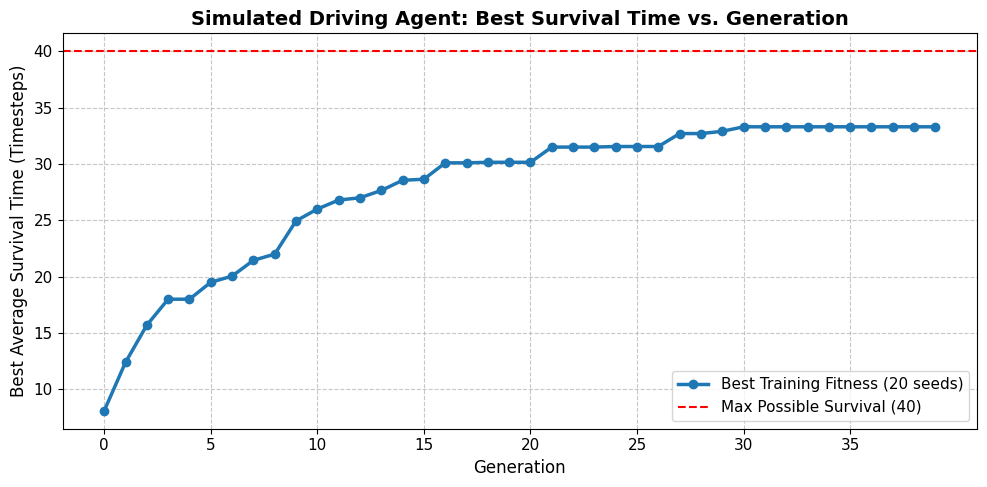

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(range(GENERATIONS), history_best_fitness, marker='o', color='#1f77b4', linewidth=2.5, label='Best Training Fitness (20 seeds)')
plt.axhline(y=EPISODE_LEN, color='r', linestyle='--', label='Max Possible Survival (40)')
plt.title("Simulated Driving Agent: Best Survival Time vs. Generation", fontsize=14, fontweight='bold')
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Best Average Survival Time (Timesteps)", fontsize=12)
plt.xticks(range(0, GENERATIONS, 5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### 9. Unseen Test Evaluation
The evolved policy was evaluated on unseen obstacle seeds (`UNSEEN_TEST_SEEDS = [777, 888, 999, 1234, 5678]`) to assess its behavior beyond the training fitness environments.


In [9]:
unseen_results = []

print("--- Unseen Test Seeds Evaluation ---")
for seed in UNSEEN_TEST_SEEDS:
    survival = run_episode(best_genome_overall, seed=seed)
    unseen_results.append(survival)
    status = "SUCCESS (Full Episode)" if survival == EPISODE_LEN else f"CRASHED at step {survival}"
    print(f"Unseen Seed {seed:4d}: Survived {survival:2d}/{EPISODE_LEN} steps | {status}")

avg_unseen = np.mean(unseen_results)
print(f"\nAverage Unseen Test Survival: {avg_unseen:.2f} / {EPISODE_LEN} timesteps")


--- Unseen Test Seeds Evaluation ---
Unseen Seed  777: Survived 12/40 steps | CRASHED at step 12
Unseen Seed  888: Survived  1/40 steps | CRASHED at step 1
Unseen Seed  999: Survived  0/40 steps | CRASHED at step 0
Unseen Seed 1234: Survived 29/40 steps | CRASHED at step 29
Unseen Seed 5678: Survived  4/40 steps | CRASHED at step 4

Average Unseen Test Survival: 9.20 / 40 timesteps


### 10. Result & Conclusion

#### Performance Analysis & Findings
1. **Generational Training Performance:**
   - Over 40 generations, the Genetic Algorithm successfully increased the average survival time across the 20 training seeds from **8.10** timesteps (Gen 0) to **33.30** timesteps (Gen 39).
2. **Unseen Test Evaluation & Generalization:**
   - Evaluating the final best genome on 5 unseen obstacle seeds (`[777, 888, 999, 1234, 5678]`) resulted in an average survival time of **9.20** timesteps.
   - The contrast between training fitness (~33.30) and unseen test survival (~9.20) illustrates that while a 40-gene lookup table effectively optimizes evasive rules for experienced obstacle patterns, full generalization across all possible random obstacle sequences requires either larger sensor lookahead or expanded state representations.
